In [ ]:
# add packages/dependencies
using ImagePhantoms
using ImageGeoms: ImageGeom
using Plots
using MIRTjim
using NFFT
using LinearMapsAA
using Random
using LaTeXStrings

include("overlayview.jl")
include("fmri.jl")

In [23]:
# set parameters
N = 256; # image size (NxN)
fov = 200; # FOV (mm)
tr = 62.5; # spoke TR (ms, matches looping star)
t_act = 20; # task on time (s)
act_lvl = 0.05; # activation level (fractional signal change)
σ_ε = 0.01; # noise std dev
nspokes = 4800; # total number of spokes
nframes = 100;

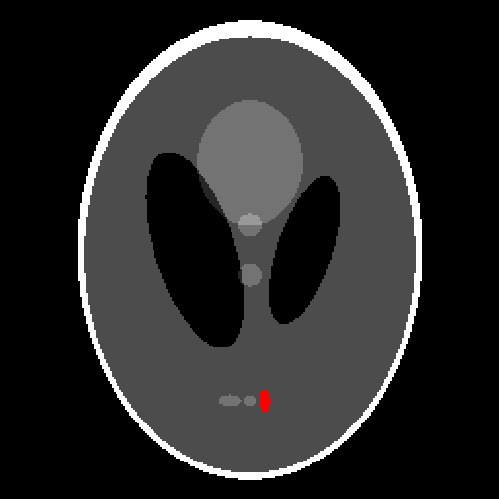

In [14]:
# create phantom
ig = ImageGeom(dims=(N, N), deltas=(fov/N, fov/N))
objects = shepp_logan(SheppLoganToft(); fovs=(fov, fov))
image = phantom(axes(ig)..., objects[1:9])
act_mask = phantom(axes(ig)..., objects[10:10]) .> 0

ov1 = ovLayer(image, (0,1));
ov2 = ovLayer(act_mask, (0,1));
ov = ovshow([ov1,ov2]);
cm1 = cgrad([:black, :white, :white, :red])
jim(axes(ig)..., ov["img_all"], color=cm1, axis=false, colorbar=false, margin=-20Plots.mm,
size=(500,500))

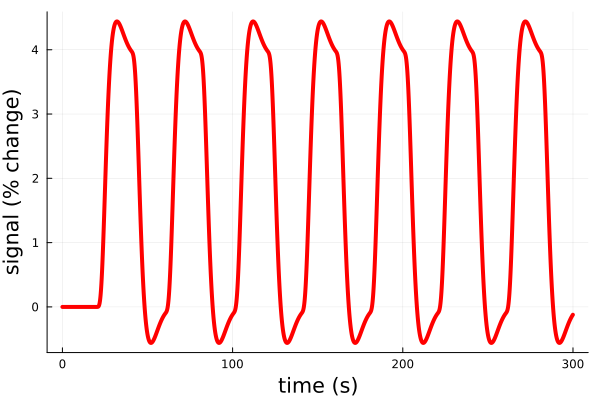

In [13]:
# create the task waveform
t = tr*1e-3 * (0:(nspokes-1)); # total time vector
task = reshape(fmri_act(t, t_act, t_act, 0), :, nspokes);
plot(t, act_lvl*100 * task[:], xlabel="time (s)", ylabel="signal (% change)", 
    xlabelfontsize = 14,
    ylabelfontsize = 14,
    label=false, lw = 4, color=:red)

┌ Info: Saved animation to /tmp/jl_VoJWrklSxk.gif
└ @ Plots /home/djfrey/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/tmp/jl_VoJWrklSxk.gif")
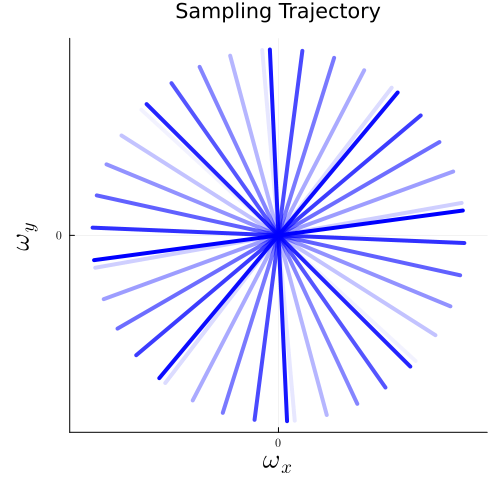

In [17]:
# create sampling trajectory and simulate k-space data
φ = pi*(3-sqrt(5))  # golden angle in radians
ktraj_raw = Array{Float32}(undef, 2*N, nspokes, 2)
for s in 1:nspokes
    ktraj_raw[:,s,:] = range(-N/fov/2, N/fov/2, 2 * N) .* [cos(s * φ), sin(s * φ)]'
end

# plot sampling trajectory
nspokes_show = 20
@gif for i in 1:2:100
    plt = plot(fov / N * 2 * ktraj_raw[:, (i+nspokes_show), 1], fov / N * 2 * ktraj_raw[:, (i+nspokes_show), 2],
        label=nothing,
        xlabel=L"\omega_x", ylabel=L"\omega_y", xlabelfontsize=18, ylabelfontsize=18,
        xticks=([-pi, 0, pi], [L"-\pi", L"0", L"\pi"]),
        yticks=([-pi, 0, pi], [L"-\pi", L"0", L"\pi"]),
        lw=4,
        aspect_ratio=1,
        color=:blue,
        size=(500, 500),
        title="Sampling Trajectory")
    for j in (i+nspokes_show-1:-1:1)
        plot!(plt,
            fov / N * 2 * ktraj_raw[:, j, 1], fov / N * 2 * ktraj_raw[:, j, 2],
            lw = 4,
            color=:blue,
            alpha=j/(i+nspokes_show),
            label=nothing)
    end
end


In [ ]:
# simulate the k-space data using the analytical Fourier transform of the phantom
kdata_raw = Array{ComplexF32}(undef, 2 * N, nspokes);
spec_bkg = spectrum(objects[1:9]); spec_act = spectrum(objects[10]);
for s in 1:nspokes
    kdata_raw[:,s] = spec_bkg.(ktraj_raw[:, s, 1], ktraj_raw[:, s, 2]); # background component
    kdata_raw[:,s] .+= act_lvl * task[:,s] .* spec_act.(ktraj_raw[:, s, 1], ktraj_raw[:, s, 2]) # activation component
end

# add complex Gaussian noise
Random.seed!(0) # for reproducibility
kdata_raw .+= σ_ε^2 / sqrt(2) * (randn(ComplexF32, size(kdata_raw)) .+ im * randn(ComplexF32, size(kdata_raw)));

In [107]:
# create data binning strategy
stride = 16 # sliding window stride (# spokes)
a_min = 32 # minimum aperature (# spokes)
ω_min = 0 # k-space radius for minimum aperature (rad)
a_max = 32 # maximum aperature (# spokes)
ω_max = pi # k-space radius for maximum aperature (rad)

# calculate sizes
M = 2 * N * nspokes; # total number of k-space samples
tildeM = a_max * 2 * N; # maximum number of samples in a frame after binning

# create aperature function (# spokes as a function of k-space radius)
a = ω -> begin
    if ω <= ω_min
        return a_min
    elseif ω >= ω_max
        return a_max
    else
        return a_min + (a_max - a_min) * (ω - ω_min) / (ω_max - ω_min)
    end
end

# create the index sample sets
# (all sample sets are the same for this radial trajectory and settings, so we just compute the unshifted set once)
ωs = pi*fov/N * vec(sqrt.(ktraj_raw[:, 1 : a_max, 1].^2 .+ ktraj_raw[:, 1 : a_max, 2].^2))
eM0 = (1:tildeM)[ abs.(-a_max*N:a_max*N-1) .<= N*a.(ωs) ] # unshifted sample index set

# set up (frame dependent) binning operator
B_f = f -> LinearMapAA(
    x -> x[(f-1)*stride*2*N .+ eM0],
    y -> begin
        x = zeros(ComplexF32, M),
        x[(f-1)*stride*2*N .+ eM0] = y
        return x
    end,
    (tildeM,M),
    idim = (M,),
    odim = (tildeM,)
)

reshape(ktraj_raw,:,2)

2457600×2 Matrix{Float32}:
  0.471916  -0.432314
  0.470069  -0.430622
  0.468222  -0.42893
  0.466375  -0.427238
  0.464528  -0.425546
  0.462681  -0.423854
  0.460834  -0.422162
  0.458987  -0.42047
  0.45714   -0.418778
  0.455293  -0.417086
  ⋮         
 -0.571801   0.239572
 -0.574112   0.24054
 -0.576422   0.241508
 -0.578732   0.242476
 -0.581043   0.243443
 -0.583353   0.244411
 -0.585663   0.245379
 -0.587974   0.246347
 -0.590284   0.247315

In [109]:
# set up big binning operator
B = LinearMapAA(
    x -> hcat([B_f(f) * x for f in 1:nframes]...),
    y -> begin
        x = zeros(ComplexF32, M)
        for f in 1:nframes
            x .+= B_f(f)' * y[:,f]
        end
        return x
    end,
    (nframes*tildeM,M),
    idim = (M,),
    odim = (tildeM,nframes)
)

LinearMapAO: 1638400 × 2457600 odim=(16384, 100) idim=(2457600,) T=Float32 Do=2 Di=1
map = 1638400×2457600 LinearMaps.FunctionMap{Float32,false}(#6, #8; issymmetric=false, ishermitian=false, isposdef=false)


In [ ]:
# set up frame-wise NUFFT operators
nuffts = Vector{Any}(undef, nframes)
ktraj = B * reshape(ktraj_raw, :, 2)
for f in 1:nframes
    nuffts[f] = plan_nfft(fov/N * ktraj[:,f,:], (N, N); m=4, σ=2.0) # create NFFT plan
end

In [113]:
# set up the acquisition model
A = LinearMapAA(
    x -> begin
        y = zeros(eltype(x),(tildeM,nframes));
        for f in 1:nframes
            y[:,f] = nuffts[f] * x[:,:,f]
        end
        return y
    end,
    y -> begin
        x = zeros(eltype(y),(N,N,nframes));
        for f in 1:nframes
            x[:,:,f] = adjoint(nuffts[f]) * y[:,f]
        end
        return x
    end,
    (tildeM*nframes, N^2*nframes), 
    idim=(N,N,nframes),
    odim=(tildeM,nframes)
)

LinearMapAO: 1638400 × 6553600 odim=(16384, 100) idim=(256, 256, 100) T=Float32 Do=2 Di=3
map = 1638400×6553600 LinearMaps.FunctionMap{Float32,false}(#6, #8; issymmetric=false, ishermitian=false, isposdef=false)


In [122]:
for f in 1:50
    # show the reconned frame
    prec = jim(axes(ig)..., x_star[:, :, f], clim=(0, 0.7), xticks=false, yticks=false, colorbar=false,
        size=(500,500), margin=-20Plots.mm)
    annotate!(prec, axes(ig)[1][1], axes(ig)[2][1], ("frame $f", 12, :white, :left, :bottom), bg=:black)
    savefig(prec, "~/Desktop/wls_recon/frame_$f.png")
end

In [123]:
# calculate the t-score map
t_hat = tr * 1e-3 * (a_max / 2 .+ stride * (0:nframes-1)) # center time of each frame (s)
GLM = fmri_act(t_hat, t_act, t_act, 0) .^ [0, 1]'; # [baseline, task]
(tscore, ~) = fmri_tscore(GLM, x_star);

In [124]:
# calculate ROC curve and AUC
nthresh = 100; # number of t-score thresholds to test
tscore_max = max(maximum(tscore[:, :, 2][act_mask]), maximum(tscore[:, :, 2][.!act_mask]))
tscore_thresh = range(tscore_max,0,nthresh); # t-score thresholds to test
TPR = Vector{Float32}(undef,nthresh);
FPR = Vector{Float32}(undef,nthresh);
for i in 1:nthresh
    ntp = count(tscore[:, :, 2][act_mask] .>= tscore_thresh[i]) # number of true positives
    nfn = count(tscore[:, :, 2][act_mask] .< tscore_thresh[i]) # number of false negatives
    nfp = count(tscore[:, :, 2][.!act_mask] .>= tscore_thresh[i]) # number of false positives
    ntn = count(tscore[:, :, 2][.!act_mask] .< tscore_thresh[i]) # number of true negatives
    TPR[i] = ntp / (ntp + nfn); # true positive rate
    FPR[i] = nfp / (nfp + ntn); # false positive rate
end
# append (0,0) and (1,1) to each axis
FPR_full = vcat(0.0, FPR, 1.0)
TPR_full = vcat(0.0, TPR, 1.0)

# compute AUC using trapezoidal rule
AUC = sum(0.5 * (TPR_full[2:end] + TPR_full[1:end-1]) .* (FPR_full[2:end] - FPR_full[1:end-1]));

# get the mean signal from the roi
mean_signal_roi = 1/count(act_mask) * vcat([sum(abs.(x_star[:,:,i])[act_mask]) for i in 1:nframes]...);

In [130]:
# plot ROC curve
proc = plot(FPR_full, TPR_full,
    xlabel="FPR", ylabel="TPR",
    background_color = :transparent,
    fillrange=0, fillcolor=:lightblue,
    label=false);
annotate!(proc, FPR[round(Int, nthresh * 0.75)], TPR[round(Int, nthresh / 2)],
    text("AUC = $(round(AUC, digits=10))", :left, :black))
savefig(proc, "~/Desktop/roc_curve.png")

"/Users/djfrey/Desktop/roc_curve.png"

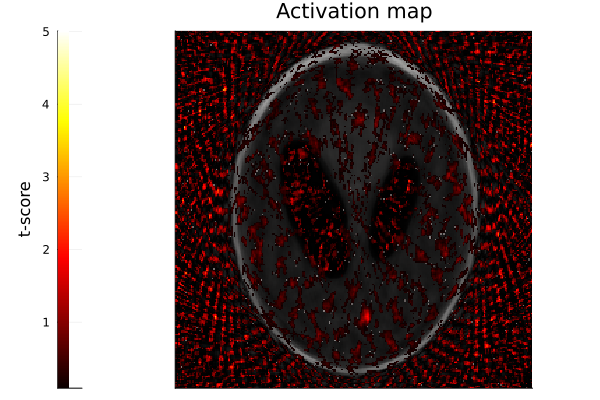

In [ ]:
# show the overlaid t-score
tscore_range = (0.1, 5);
ov0 = ovLayer(abs.(x_star[:, :, 1]), (0, 1));
ov1 = ovLayer(tscore[:, :, 2], tscore_range; color=:hot);
O = ovshow([ov0, ov1])
povl = jim(axes(ig)..., O["img_all"]; color=O["color_all"], clim=O["clim_all"],
    colorbar=false, xticks=false, yticks=false)
pcb = heatmap(ones((1,)), range(tscore_range[1], tscore_range[2], 256),
    reshape(range(tscore_range[1], tscore_range[2], 256), (256, 1)),
    xticks=false, color=:hot, colorbar=false,
    xlim=(1, 1), ylabel="t-score",
    aspect_ratio=3)
pact = plot(pcb, povl, background_color = :transparent, layout=@layout [a{0.1w} b{0.9w}])

In [126]:
show_plots = false # set to true if you want to see the plots :)

# show the windowing functions
ncycles_show = 10
kr_show = range(0, N / fov / 2, 100)
t_show = range(0, min(t[end], t_act*ncycles_show), 1000)
normalize = x -> (x .- minimum(x)) ./ (maximum(x) - minimum(x))

# display the task waveform and mean signal in roi
psig = plot(t_show, normalize(fmri_act(t_show,t_act,t_act,0)), label="task",
    xlabel="time (s)", ylabel="signal",
    ylim=(0,1), yticks=false
)
plot!(psig, t_hat, normalize(mean_signal_roi),
    label="mean signal (roi)",
    xlim=(0, t_act*ncycles_show)
)

# show the windowing functions
t_sub = range(-tr*1e-3, (a_max + stride + 1)*tr*1e-3, 100)
pwin = plot(
    heatmap(t_sub, kr_show, window.(t_hat[1] / (tr * 1e-3), t_sub' / (tr * 1e-3), kr_show),
        xticks=false, xlabel=nothing, title="frame 1 windowing function"), # 1st frame
    heatmap(t_sub, kr_show, window.(t_hat[2] / (tr * 1e-3), t_sub' / (tr * 1e-3), kr_show),
        xlabel="time(s)", title="frame 2 windowing function"), # 2nd frame
    layout = (2,1),
    ylim=(0, N / fov / 2),
    color=window_color, colorbar=false,
    ylabel=L"|k|",
    yticks=((0, N / fov / 2), ("0", L"k_\mathrm{max}")))

# show the overlaid t-score
tscore_range = (0.1, 5);
ov0 = ovLayer(abs.(x_star[:, :, 1]), (0, 1));
ov1 = ovLayer(tscore[:, :, 2], tscore_range; color=:hot);
O = ovshow([ov0, ov1])
povl = jim(axes(ig)..., O["img_all"]; color=O["color_all"], clim=O["clim_all"],
    colorbar=false, xticks=false, yticks=false,
    title="Activation map")
pcb = heatmap(ones((1,)), range(tscore_range[1], tscore_range[2], 256),
    reshape(range(tscore_range[1], tscore_range[2], 256), (256, 1)),
    xticks=false, color=:hot, colorbar=false,
    xlim=(1, 1), ylabel="t-score",
    aspect_ratio=3)
pact = plot(pcb, povl,  layout=@layout [a{0.1w} b{0.9w}])

# plot ROC curve
proc = plot(FPR_full, TPR_full,
    xlabel="FPR", ylabel="TPR",
    title="ROC Curve",
    fillrange=0, fillcolor=:lightblue,
    label=false);
annotate!(proc, FPR[round(Int, nthresh * 0.75)], TPR[round(Int, nthresh / 2)],
    text("AUC = $(round(AUC, digits=10))", :left, :black))

if show_plots
    # save a big ol figure with all the results
    @gif for f in 1:min(nframes,50)
        # show the reconned frame
        prec = jim(axes(ig)..., x_star[:, :, f], clim=(0, 0.7), xticks=false, yticks=false, colorbar=false,
            title="frame-wise recon")
        annotate!(prec, axes(ig)[1][1], axes(ig)[2][1], ("frame $f", 12, :white, :left, :bottom), bg=:black)

        # plot all
        p_sub2 = plot(pwin, prec, layout=@layout [a{0.5w} b{0.5w}])
        p_sub3 = plot(proc, pact, layout=@layout [a{0.4w} b{0.6w}])
        plot(
            psig,
            p_sub2,
            p_sub3,
            size=(900, 1200),
            layout=@layout [a{0.2h}; b{0.4h}; c{0.4h}]
        );
    end
end